# Supplementary Figure S7: `s07_success_rate`

**Feature-accentuation success rate.** Across all synthesized stimuli, the achieved level (each generating model's post-hoc predicted response for the saved image) is compared to its intended target, and a synthesis is scored successful when the miss (i.e., the relative error), $|\mathrm{target}-\mathrm{achieved}|/\mathrm{range}$, falls within tolerance $\tau$, where $\mathrm{range}$ is the per-channel target range. Overall success was $94.5%$ at $\tau = 5%$ and $90.7%$ at $\tau = 2%$. (A) The ten seed images used in feature accentuation. (B) Histograms are shown of the miss quantities (% of channel target range) pooled over all stimuli, with dashed lines marking the $2%$ (orange) and $5%$ (red) thresholds; note that a majority of the stimuli concentrate near zero. Inset magnifies the $y$-axis ($\times 80$) to expose the tail beyond the main peak. (C) Per-model success rate at $\tau = 5%$ for the 10 models, colored by model, with the dotted line and label marking the overall rate ($94.5%$); rates are consistently high across all models. (D) Success rate at $\tau = 5%$ versus the 11 ordinal drive levels (suppress to drive), one faint trace per model and the bold black trace pooling all models; success stays near ceiling through the mid-range and falls off only at the most extreme drive levels.

Rendered by `figures/supplementary/sup_success_rate.py`; the PNG written below is pixel-identical to the manuscript file `s07_success_rate.png` in the reference environment (see docs/REPRODUCIBILITY.md). The preview shown here is downscaled.

In [1]:
import os, sys
from pathlib import Path

# Keep BLAS single-threaded: multithreaded OpenMP together with torch can kill the kernel on macOS.
for _v in ('OMP_NUM_THREADS', 'OPENBLAS_NUM_THREADS', 'MKL_NUM_THREADS', 'VECLIB_MAXIMUM_THREADS'):
    os.environ.setdefault(_v, '1')
os.environ.setdefault('KMP_DUPLICATE_LIB_OK', 'TRUE')

# Render with the Agg backend and matplotlib's defaults, exactly like the figure scripts;
# Jupyter's inline backend would otherwise change dpi and bounding boxes.
os.environ['MPLBACKEND'] = 'Agg'
import matplotlib; matplotlib.use('Agg'); matplotlib.rcdefaults()

# Work from the repository root whether the notebook is opened there or in notebooks/figures/.
REPO = Path.cwd() if (Path.cwd() / 'pnc').exists() else Path.cwd().parents[1]
sys.path.insert(0, str(REPO))
from pnc import paths

# The figures read the preprocessed caches only; this raises a clear message if they are missing.
paths.require(paths.preprocessed_data() / 'brain_red.pkl')   # python data/download_data.py --tier preprocessed
out_dir = paths.output_dir() / 'figures'
out_dir.mkdir(parents=True, exist_ok=True)

In [2]:
from figures.supplementary.sup_success_rate import main

# main() writes <out_dir>/<manuscript name>.png (border-trimmed, so it matches the submitted file)
# and returns its path; keyword arguments select the non-default variants documented in the script.
png = main(str(out_dir))
print(png)

Saved -> /private/tmp/claude-501/-Users-jacobprince-KonkLab-Dropbox-Jacob-Prince-Research-Prince-Accentuate-VVS-Manuscript/bca6882d-ec2d-4dbd-beb1-0d67d8b1fcc7/scratchpad/nb_exec_out/figures/s07_success_rate.png
N stimuli (finite relerr): 27720
Overall success @5%: 94.5%
Overall success @2%: 90.7%
Per-model success rate @5%:
  Untrained    (AlexNet_training_seed_01  )  87.5%
  SigLIP2      (siglip2_vitb16            )  92.8%
  RN50-CLIP    (resnet50_clip             )  93.3%
  RegNetY      (regnety_640               )  98.7%
  DINOv2       (dinov2_vitb14_reg         )  97.3%
  RADIO        (radio_v2.5-b              )  92.0%
  ResNet50     (resnet50                  )  98.8%
  RN50-DINO    (resnet50_dino             )  99.9%
  RN50-Robust  (resnet50_robust           )  91.2%
  CLIPAG       (clipag_vitb32             )  93.9%
/private/tmp/claude-501/-Users-jacobprince-KonkLab-Dropbox-Jacob-Prince-Research-Prince-Accentuate-VVS-Manuscript/bca6882d-ec2d-4dbd-beb1-0d67d8b1fcc7/scratchpad/n

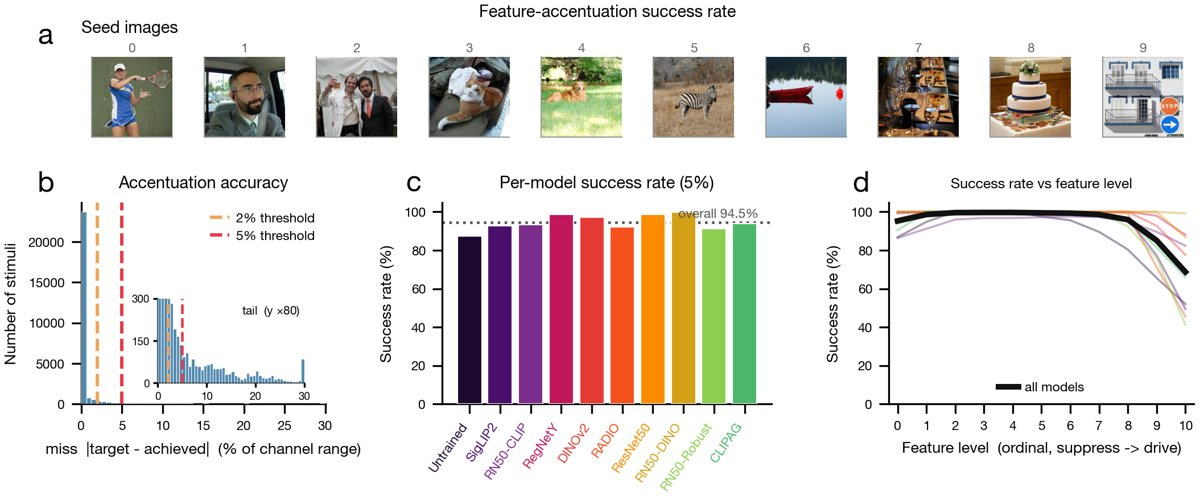

In [3]:
import io
from IPython.display import Image, display
from PIL import Image as PILImage

# Show a downscaled JPEG preview (the full-resolution PNG can be tens of MB); open the file for detail.
im = PILImage.open(png).convert("RGB")
im.thumbnail((1200, 1200))
buf = io.BytesIO(); im.save(buf, "JPEG", quality=85, optimize=True)
display(Image(data=buf.getvalue(), format="jpeg", width=900))